In [215]:
import pandas as pd
import matplotlib as plt
import seaborn as sns 

In [216]:
car = pd.read_csv("austo_automobile.csv")

# data collection 

In [217]:
car.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


# data profiling

In [218]:
print("number of records : ",car.shape[0])
print("number of columns : ",car.shape[1])



number of records :  1581
number of columns :  14


In [219]:
car.columns

Index(['Age', 'Gender', 'Profession', 'Marital_status', 'Education',
       'No_of_Dependents', 'Personal_loan', 'House_loan', 'Partner_working',
       'Salary', 'Partner_salary', 'Total_salary', 'Price', 'Make'],
      dtype='str')

In [220]:
car.info()

<class 'pandas.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   str    
 2   Profession        1581 non-null   str    
 3   Marital_status    1581 non-null   str    
 4   Education         1581 non-null   str    
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   str    
 7   House_loan        1581 non-null   str    
 8   Partner_working   1581 non-null   str    
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   str    
dtypes: float64(1), int64(5), str(8)
memory usage: 173.1 KB


In [221]:
car.duplicated().sum()



np.int64(0)

In [222]:
car.isnull().sum()

#check the missing value

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

In [223]:
car.Education.unique()

<StringArray>
['Post Graduate', 'Graduate']
Length: 2, dtype: str

In [224]:
car.Marital_status.unique()

<StringArray>
['Married', 'Single']
Length: 2, dtype: str

In [225]:
car.dtypes[car.dtypes == "str"].index

Index(['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan',
       'House_loan', 'Partner_working', 'Make'],
      dtype='str')

In [226]:
#for finding unique of all coulmns at same time 


car[['Gender','Profession','Marital_status','Education','Personal_loan','House_loan','Partner_working','Make']].apply(lambda x: x.unique())

Gender             [Male, Femal, Female, nan, Femle]
Profession                      [Business, Salaried]
Marital_status                     [Married, Single]
Education                  [Post Graduate, Graduate]
Personal_loan                              [No, Yes]
House_loan                                 [No, Yes]
Partner_working                            [Yes, No]
Make                         [SUV, Sedan, Hatchback]
dtype: object

In [227]:
car.Gender = car.Gender.replace(["Femal","Femle"],["Female","Female"])

#replace incorect words (Femal,Femle) with correct word (Female)

In [228]:
car.Gender.value_counts()

Gender
Male      1199
Female     329
Name: count, dtype: int64

In [229]:
car.Gender = car.Gender.fillna("Male")

#replace missing value with male in Gender,because male is most frequent coustmer in this data 

In [230]:
car.isnull().sum()

Age                   0
Gender                0
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

In [231]:
car.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1475.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,20225.559322,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19573.149277,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25600.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38300.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


In [232]:
car.Partner_salary = car.Total_salary - car.Salary

# fill the null values of partner salary by subtraction of salary with total salary

In [233]:
car.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

# univariate analysis

<Axes: xlabel='Gender'>

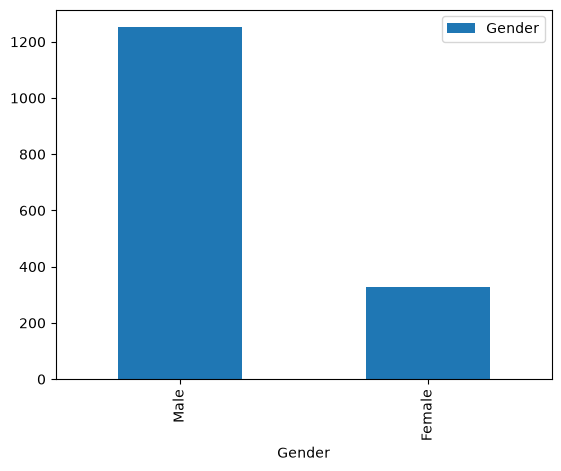

In [234]:
pd.DataFrame(car.Gender.value_counts()).rename(columns={"count":"Gender"}).plot.bar()


<Axes: xlabel='Make'>

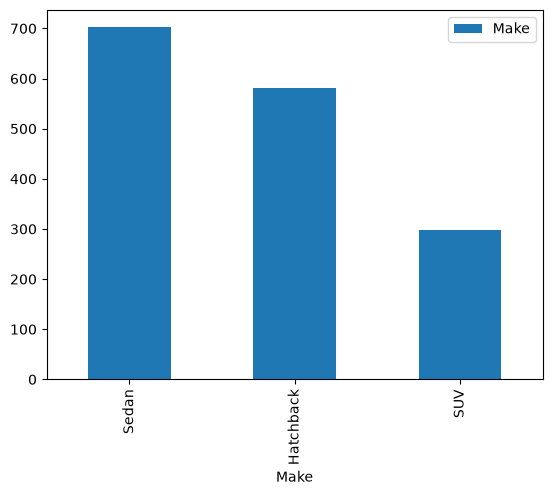

In [235]:
pd.DataFrame(car.Make.value_counts()).rename(columns={"count":"Make"}).plot.bar()

<Axes: xlabel='House_loan'>

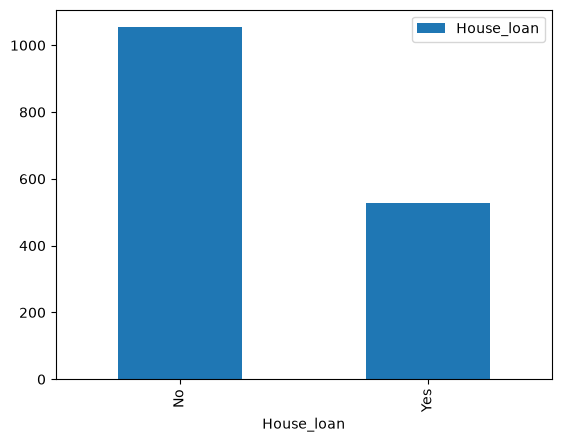

In [236]:
pd.DataFrame(car.House_loan.value_counts()).rename(columns={"count":"House_loan"}).plot.bar()

<Axes: xlabel='Education'>

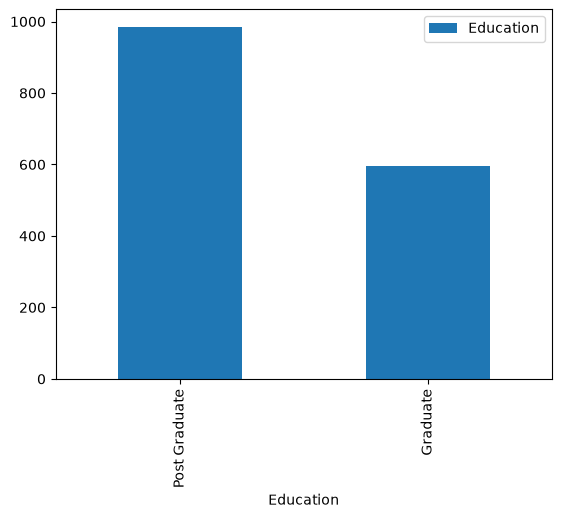

In [237]:
pd.DataFrame(car.Education.value_counts()).rename(columns={"count":"Education"}).plot.bar()

<Axes: xlabel='Marital_status'>

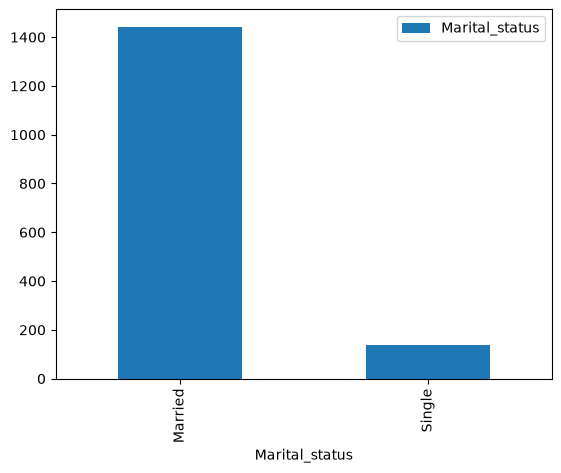

In [238]:
pd.DataFrame(car.Marital_status.value_counts()).rename(columns={"count":"Marital_status"}).plot.bar()

<Axes: xlabel='Profession'>

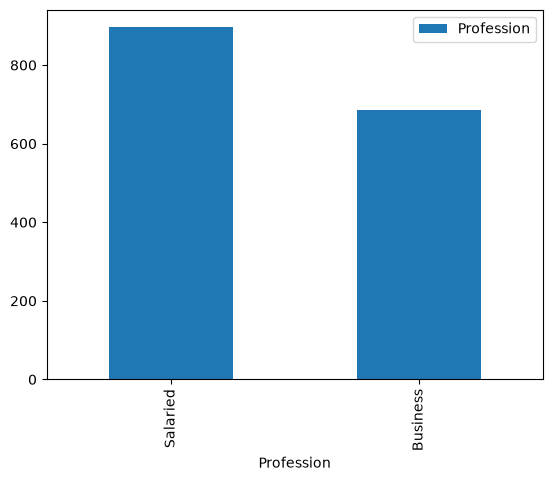

In [239]:
pd.DataFrame(car.Profession.value_counts()).rename(columns={"count":"Profession"}).plot.bar()

<Axes: xlabel='Partner_working'>

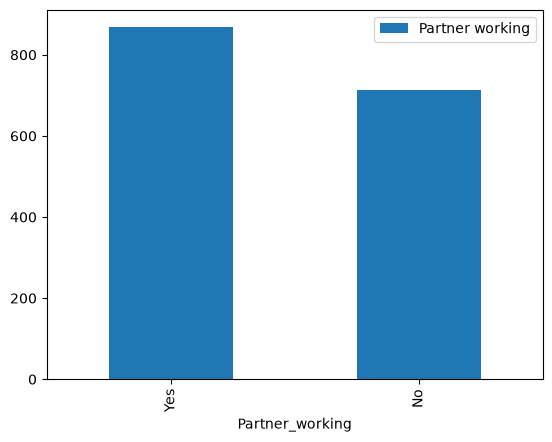

In [240]:
pd.DataFrame(car.Partner_working.value_counts()).rename(columns={"count":"Partner working"}).plot.bar()

<Axes: xlabel='Age', ylabel='Count'>

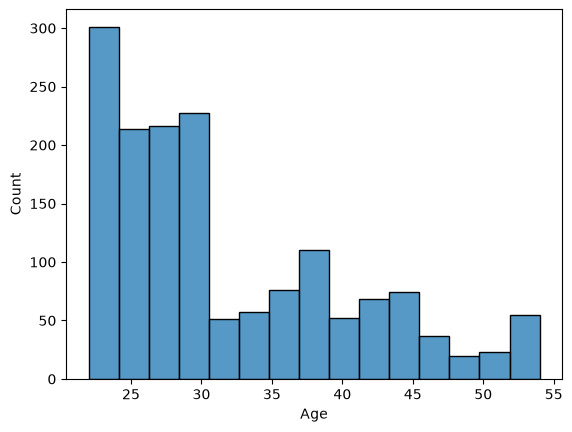

In [241]:
sns.histplot(car.Age)

<Axes: xlabel='Salary', ylabel='Count'>

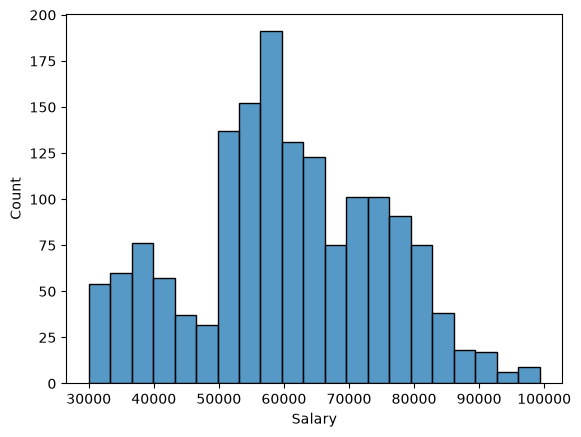

In [242]:
sns.histplot(car.Salary)

<Axes: xlabel='Partner_salary', ylabel='Count'>

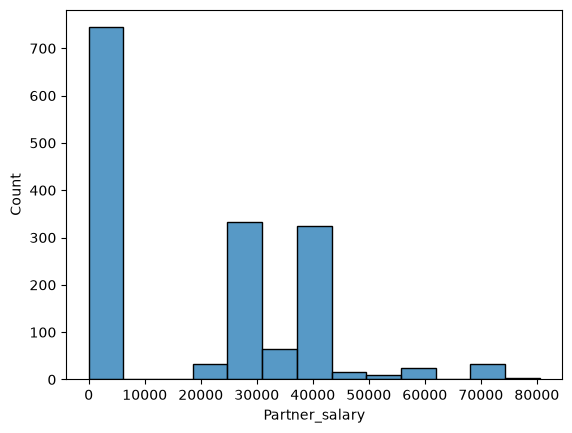

In [243]:
sns.histplot(car.Partner_salary)

<Axes: xlabel='Price', ylabel='Count'>

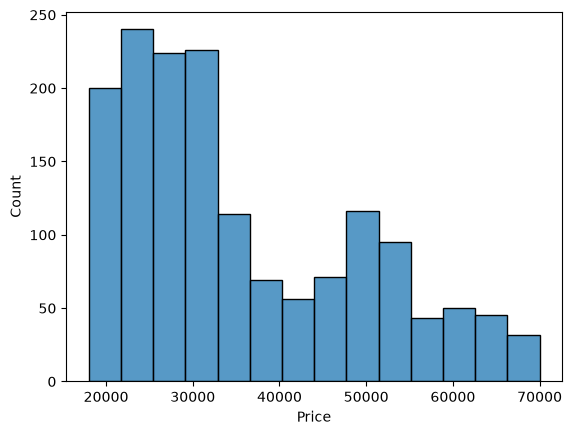

In [244]:
sns.histplot(car.Price)

<Axes: xlabel='Total_salary', ylabel='Count'>

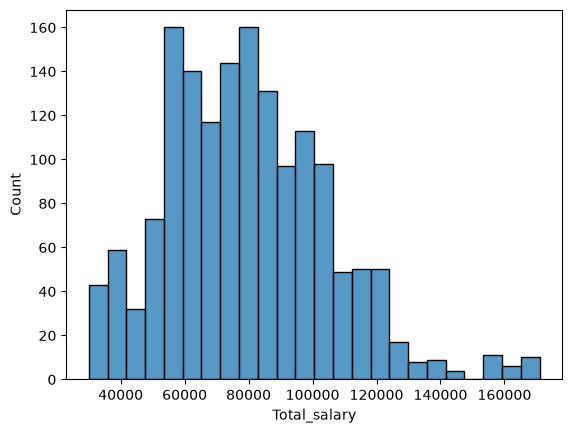

In [245]:
sns.histplot(car.Total_salary)

# bi-variate Analysis

In [246]:
car.pivot_table(index="Gender",columns="Profession",aggfunc="count")["Age"]

Profession,Business,Salaried
Gender,,
Female,105,224
Male,580,672


In [247]:
car.pivot_table(index="Gender",columns="Make",aggfunc="count")["Age"]

Make,Hatchback,SUV,Sedan
Gender,,,
Female,15,173,141
Male,567,124,561


In [248]:
car.pivot_table(index="Gender",columns="Profession",aggfunc="count")["Age"]

Profession,Business,Salaried
Gender,,
Female,105,224
Male,580,672


In [249]:
car.pivot_table(index="Gender",columns="House_loan",aggfunc="count")["Age"]

House_loan,No,Yes
Gender,,
Female,244,85
Male,810,442


In [250]:
car.pivot_table(index="Gender",columns="Marital_status",aggfunc="count")["Age"]

Marital_status,Married,Single
Gender,,
Female,307,22
Male,1136,116


In [251]:
car.pivot_table(index="Gender",columns="Partner_working",aggfunc="count")["Age"]

Partner_working,No,Yes
Gender,,
Female,151,178
Male,562,690


In [252]:
MaleData = car[car.Gender=="Male"][["Gender","Make"]]
MaleData

,Gender,Make
0,Male,SUV
4,Male,SUV
7,Male,SUV
8,Male,SUV
9,Male,SUV
...,...,...
1576,Male,Hatchback
1577,Male,Hatchback
1578,Male,Hatchback
1579,Male,Hatchback


In [253]:
sample1 =MaleData.sample(329).groupby("Make").count().rename(columns={"Gender":"Make"})
sample1

,Make
Make,
Hatchback,147
SUV,35
Sedan,147


In [254]:
sample2 =MaleData.sample(329).groupby("Make").count().rename(columns={"Gender":"Make"})
sample2

,Make
Make,
Hatchback,160
SUV,38
Sedan,131


In [255]:
sample3 =MaleData.sample(329).groupby("Make").count().rename(columns={"Gender":"Make"})
sample3

,Make
Make,
Hatchback,155
SUV,33
Sedan,141


In [256]:
sample4 =MaleData.sample(329).groupby("Make").count().rename(columns={"Gender":"Make"})
sample4

,Make
Make,
Hatchback,156
SUV,30
Sedan,143


In [257]:
FemaleData = car[car.Gender=="Female"][["Gender","Make"]]


In [258]:
fem = FemaleData.groupby("Make").count().rename(columns={"Gender":"Female"})
fem

,Female
Make,
Hatchback,15
SUV,173
Sedan,141


<Axes: xlabel='Make'>

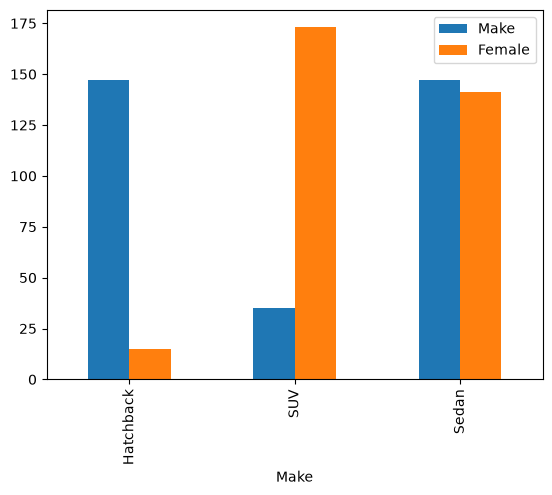

In [259]:
# I am not agree with Steve.. Females are more interested in suv over male 

pd.concat([sample1,fem],axis=1).plot.bar()
 

<Axes: xlabel='Make'>

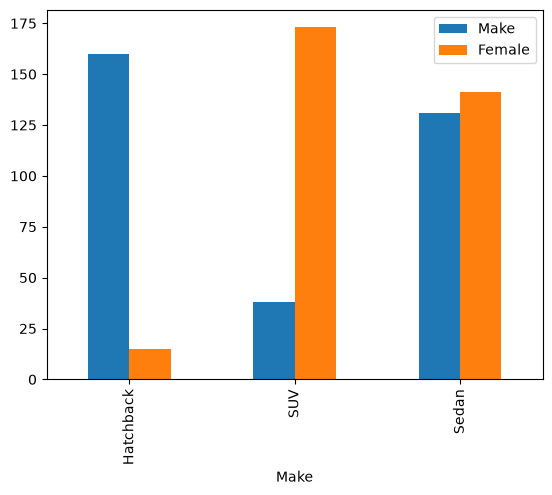

In [260]:
pd.concat([sample2,fem],axis=1).plot.bar()

<Axes: xlabel='Make'>

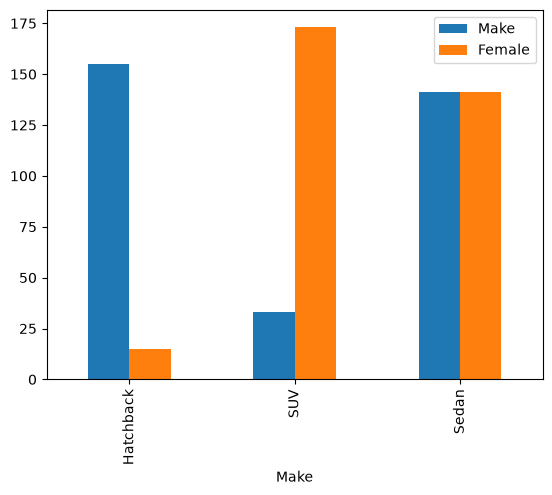

In [261]:
pd.concat([sample3,fem],axis=1).plot.bar()

<Axes: xlabel='Make'>

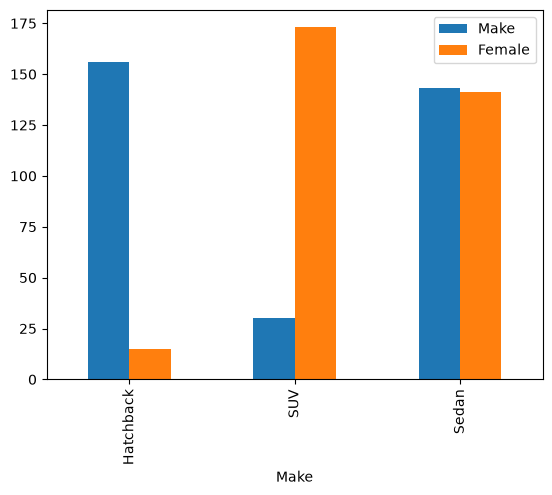

In [262]:
pd.concat([sample4,fem],axis=1).plot.bar()

In [263]:
sample1 = pd.DataFrame(sample1)

In [264]:
suvm = [ sample1.iloc[1,0],sample2.iloc[1,0],sample3.iloc[1,0],sample4.iloc[1,0] ]
suvf = [ fem.iloc[1,0],fem.iloc[1,0],fem.iloc[1,0],fem.iloc[1,0]   ]

<Axes: >

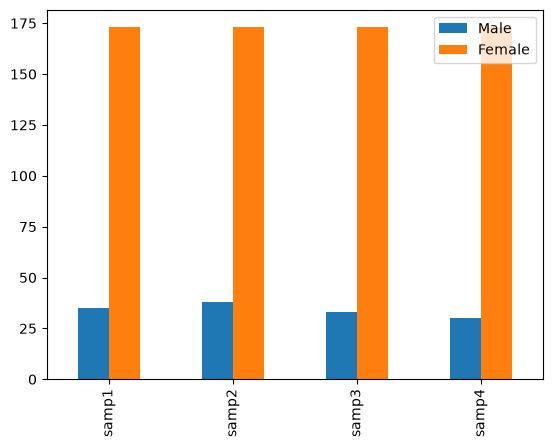

In [265]:
pd.DataFrame({"Male":suvm,"Female":suvf},index=["samp1","samp2","samp3","samp4"]).plot.bar()

# profession and Make 

In [266]:
car.pivot_table(index="Profession",columns="Make",aggfunc="count")["Age"]

Make,Hatchback,SUV,Sedan
Profession,,,
Business,290,89,306
Salaried,292,208,396


In [267]:
MaleData = car[car.Gender=="Male"][["Profession","Make"]]
MaleData

,Profession,Make
0,Business,SUV
4,Salaried,SUV
7,Salaried,SUV
8,Salaried,SUV
9,Salaried,SUV
...,...,...
1576,Salaried,Hatchback
1577,Business,Hatchback
1578,Business,Hatchback
1579,Business,Hatchback


In [268]:
sample1 = MaleData.sample(329).groupby(["Make","Profession"])["Make"].count()
sample1

Make       Profession
Hatchback  Business      77
           Salaried      78
SUV        Business      12
           Salaried      28
Sedan      Business      52
           Salaried      82
Name: Make, dtype: int64

In [269]:
sample2 = MaleData.sample(329).groupby(["Make","Profession"])["Make"].count()
sample2

Make       Profession
Hatchback  Business      71
           Salaried      70
SUV        Business       7
           Salaried      32
Sedan      Business      67
           Salaried      82
Name: Make, dtype: int64

In [270]:
sample3 = MaleData.sample(329).groupby(["Make","Profession"])["Make"].count()
sample3

Make       Profession
Hatchback  Business      66
           Salaried      70
SUV        Business      10
           Salaried      33
Sedan      Business      62
           Salaried      88
Name: Make, dtype: int64

In [271]:
FemaleData = car[car.Gender=="Female"][["Profession","Make"]]

In [272]:
fem = FemaleData.groupby(["Make","Profession"])["Make"].count()
fem

Make       Profession
Hatchback  Salaried       15
SUV        Business       55
           Salaried      118
Sedan      Business       50
           Salaried       91
Name: Make, dtype: int64

<Axes: xlabel='Make,Profession'>

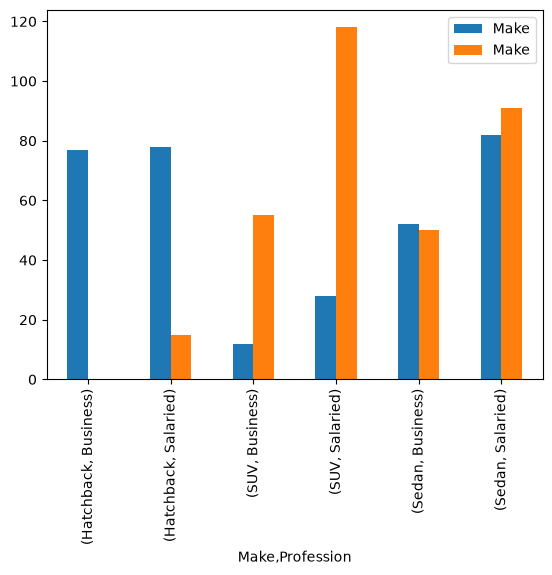

In [273]:
pd.concat([sample1,fem],axis=1).plot.bar()

<Axes: xlabel='Make,Profession'>

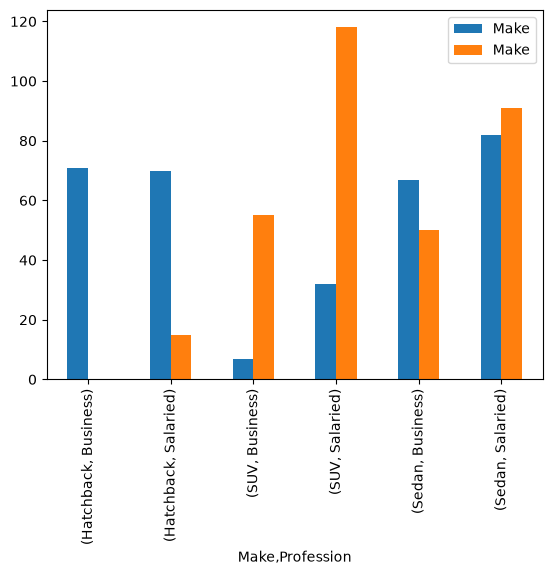

In [274]:
pd.concat([sample2,fem],axis=1).plot.bar()

<Axes: xlabel='Make,Profession'>

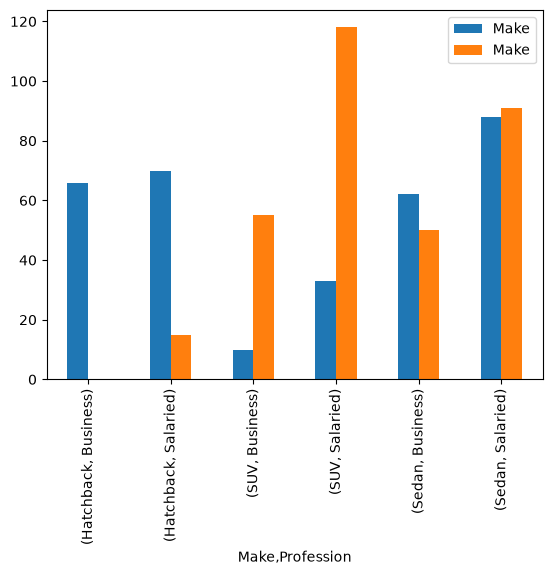

In [275]:
pd.concat([sample3,fem],axis=1).plot.bar()

In [276]:
# After the Analysis I can satisfied witth the Ned stark concultion that salried person are more likely to buy the Seadan 

In [277]:
# I don't agree with Sheldon Cooper's stament because mostly salaried male are more likely to buy Seadan over the Suv 

# martital status and make

In [278]:
MaleData = car[car.Gender=="Male"][["Marital_status","Make","Gender"]]
MaleData

,Marital_status,Make,Gender
0,Married,SUV,Male
4,Married,SUV,Male
7,Married,SUV,Male
8,Married,SUV,Male
9,Married,SUV,Male
...,...,...,...
1576,Single,Hatchback,Male
1577,Married,Hatchback,Male
1578,Single,Hatchback,Male
1579,Married,Hatchback,Male


In [279]:
sample1 = MaleData.sample(329).groupby(["Marital_status","Make"])["Gender"].count()
sample1

Marital_status  Make     
Married         Hatchback    123
                SUV           33
                Sedan        144
Single          Hatchback     19
                SUV            3
                Sedan          7
Name: Gender, dtype: int64

In [280]:
sample2 = MaleData.sample(329).groupby(["Marital_status","Make"])["Gender"].count()
sample2

Marital_status  Make     
Married         Hatchback    115
                SUV           22
                Sedan        163
Single          Hatchback     19
                SUV            4
                Sedan          6
Name: Gender, dtype: int64

In [281]:
sample3 = MaleData.sample(329).groupby(["Marital_status","Make"])["Gender"].count()
sample3

Marital_status  Make     
Married         Hatchback    137
                SUV           22
                Sedan        135
Single          Hatchback     27
                SUV            2
                Sedan          6
Name: Gender, dtype: int64

In [282]:
FemaleData = car[car.Gender=="Female"][["Marital_status","Make","Gender"]]

In [283]:
fem = FemaleData.groupby(["Marital_status","Make"])["Gender"].count()
fem

Marital_status  Make     
Married         Hatchback     14
                SUV          166
                Sedan        127
Single          Hatchback      1
                SUV            7
                Sedan         14
Name: Gender, dtype: int64

<Axes: xlabel='Marital_status,Make'>

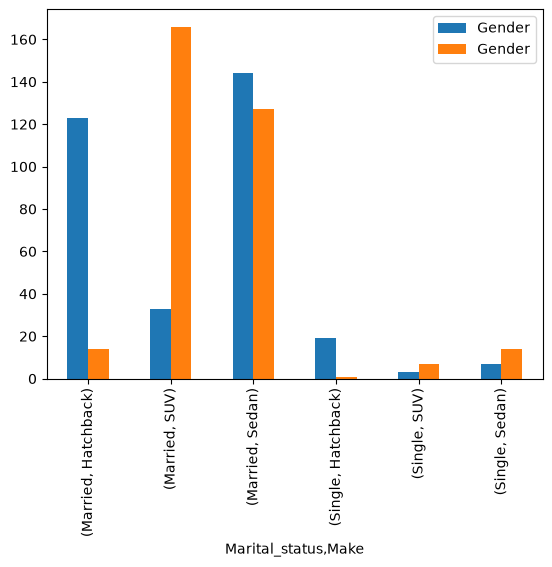

In [284]:
pd.concat([sample1,fem],axis=1).plot.bar()

<Axes: xlabel='Marital_status,Make'>

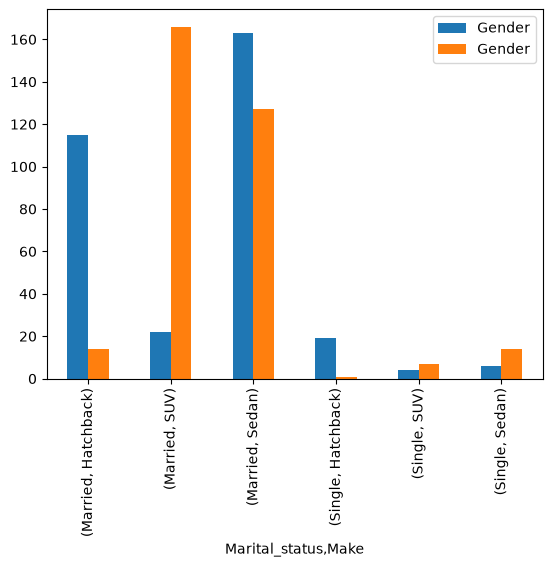

In [285]:
pd.concat([sample2,fem],axis=1).plot.bar()

<Axes: xlabel='Marital_status,Make'>

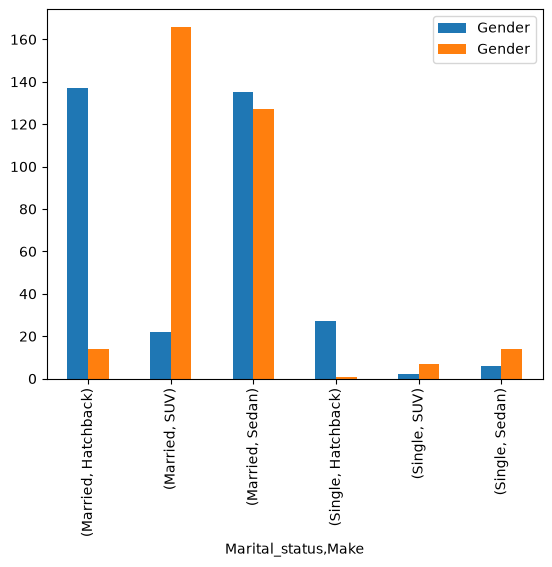

In [286]:
pd.concat([sample3,fem],axis=1).plot.bar()

In [287]:
# married person are more buying cars than single person 

# single women mostly perfer Seadan as per my analysis 

# marrid Male are mostly perefer seadan and Hatch back over suv 

# Education and make

In [288]:
MaleData = car[car.Gender=="Male"][["Education","Make","Gender"]]
MaleData

,Education,Make,Gender
0,Post Graduate,SUV,Male
4,Post Graduate,SUV,Male
7,Graduate,SUV,Male
8,Post Graduate,SUV,Male
9,Post Graduate,SUV,Male
...,...,...,...
1576,Graduate,Hatchback,Male
1577,Graduate,Hatchback,Male
1578,Graduate,Hatchback,Male
1579,Graduate,Hatchback,Male


In [289]:
sample1 = MaleData.sample(329).groupby(["Education","Make"])["Gender"].count()
sample1

Education      Make     
Graduate       Hatchback    70
               SUV          11
               Sedan        37
Post Graduate  Hatchback    93
               SUV          24
               Sedan        94
Name: Gender, dtype: int64

In [290]:
sample2 = MaleData.sample(329).groupby(["Education","Make"])["Gender"].count()
sample2

Education      Make     
Graduate       Hatchback    56
               SUV          14
               Sedan        62
Post Graduate  Hatchback    91
               SUV          23
               Sedan        83
Name: Gender, dtype: int64

In [291]:
sample3 = MaleData.sample(329).groupby(["Education","Make"])["Gender"].count()
sample3

Education      Make     
Graduate       Hatchback    70
               SUV           7
               Sedan        53
Post Graduate  Hatchback    88
               SUV          20
               Sedan        91
Name: Gender, dtype: int64

In [292]:
FemaleData = car[car.Gender == "Female"][["Education","Make","Gender"]]
FemaleData


,Education,Make,Gender
1,Post Graduate,SUV,Female
2,Post Graduate,SUV,Female
3,Graduate,SUV,Female
5,Post Graduate,SUV,Female
6,Post Graduate,SUV,Female
...,...,...,...
1350,Post Graduate,Hatchback,Female
1389,Post Graduate,Hatchback,Female
1503,Post Graduate,Hatchback,Female
1518,Post Graduate,Hatchback,Female


In [293]:
fem = FemaleData.groupby(["Education","Make"])["Gender"].count()
fem

Education      Make     
Graduate       Hatchback      5
               SUV           73
               Sedan         60
Post Graduate  Hatchback     10
               SUV          100
               Sedan         81
Name: Gender, dtype: int64

<Axes: xlabel='Education,Make'>

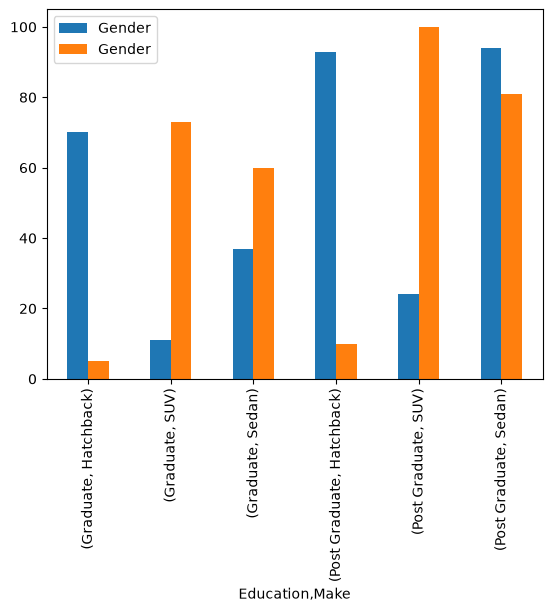

In [294]:
pd.concat([sample1,fem],axis=1).plot.bar()

<Axes: xlabel='Education,Make'>

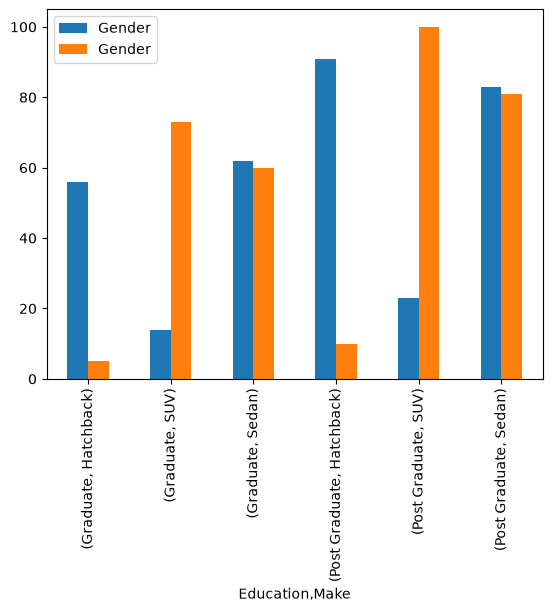

In [295]:
pd.concat([sample2,fem],axis=1).plot.bar()

<Axes: xlabel='Education,Make'>

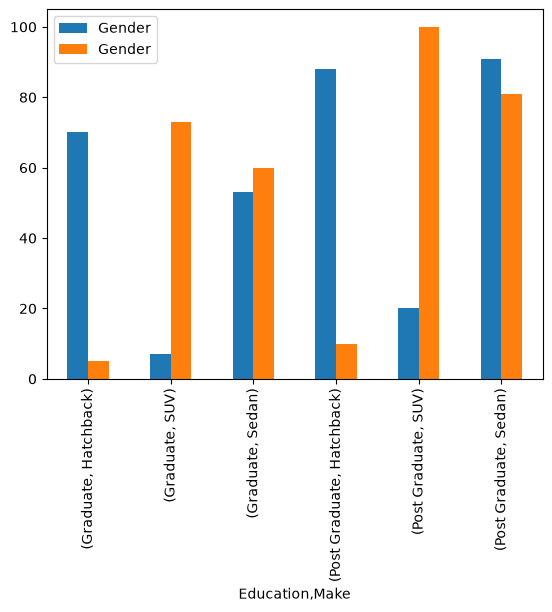

In [296]:
pd.concat([sample3,fem],axis=1).plot.bar()

In [297]:
# PG person buy more car than Graduate person in all sagement of car 

# personal loan and make 

In [298]:
MaleData = car[car.Gender == "Male"][["Personal_loan","Make","Gender"]]
MaleData

,Personal_loan,Make,Gender
0,No,SUV,Male
4,No,SUV,Male
7,No,SUV,Male
8,No,SUV,Male
9,No,SUV,Male
...,...,...,...
1576,No,Hatchback,Male
1577,No,Hatchback,Male
1578,No,Hatchback,Male
1579,Yes,Hatchback,Male


In [299]:
FemaleData = car[car.Gender =="Female"][["Personal_loan","Make","Gender"]]
FemaleData

,Personal_loan,Make,Gender
1,Yes,SUV,Female
2,No,SUV,Female
3,Yes,SUV,Female
5,No,SUV,Female
6,Yes,SUV,Female
...,...,...,...
1350,No,Hatchback,Female
1389,Yes,Hatchback,Female
1503,No,Hatchback,Female
1518,No,Hatchback,Female


In [300]:
sample1 = MaleData.sample(329).groupby(["Personal_loan","Make"])["Gender"].count()
sample1

Personal_loan  Make     
No             Hatchback    60
               SUV          25
               Sedan        64
Yes            Hatchback    78
               SUV          10
               Sedan        92
Name: Gender, dtype: int64

In [301]:
sample2 = MaleData.sample(329).groupby(["Personal_loan","Make"])["Gender"].count()
sample2

Personal_loan  Make     
No             Hatchback    65
               SUV          36
               Sedan        58
Yes            Hatchback    84
               SUV           8
               Sedan        78
Name: Gender, dtype: int64

In [302]:
sample3 = MaleData.sample(329).groupby(["Personal_loan","Make"])["Gender"].count()
sample3

Personal_loan  Make     
No             Hatchback    72
               SUV          14
               Sedan        66
Yes            Hatchback    78
               SUV          17
               Sedan        82
Name: Gender, dtype: int64

In [303]:
fem = FemaleData.groupby(["Personal_loan","Make"])["Gender"].count()
fem


Personal_loan  Make     
No             Hatchback     10
               SUV          101
               Sedan         69
Yes            Hatchback      5
               SUV           72
               Sedan         72
Name: Gender, dtype: int64

<Axes: xlabel='Personal_loan,Make'>

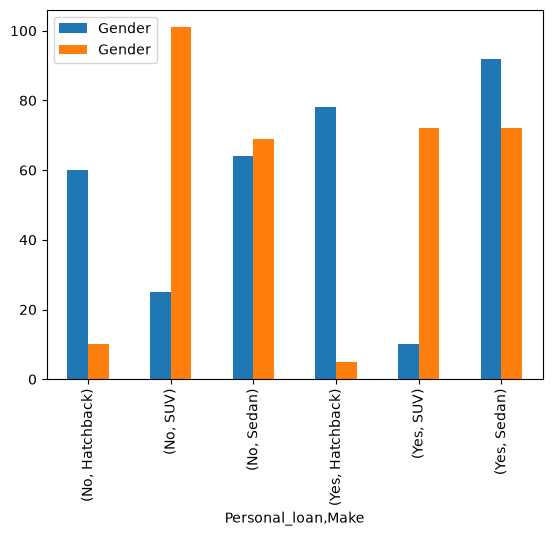

In [304]:
pd.concat([sample1,fem],axis=1).plot.bar()

<Axes: xlabel='Personal_loan,Make'>

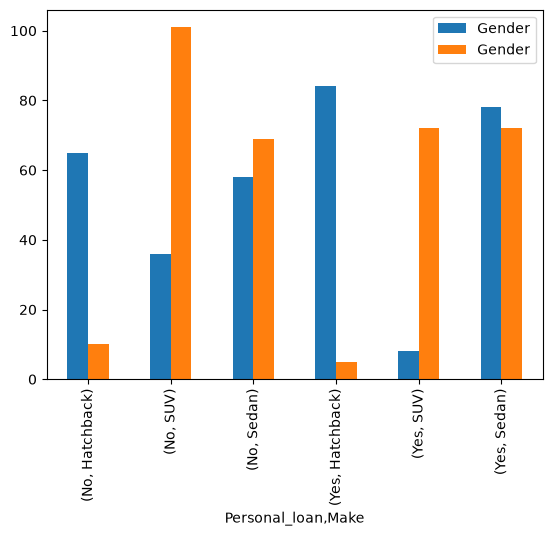

In [305]:
pd.concat([sample2,fem],axis=1).plot.bar()

<Axes: xlabel='Personal_loan,Make'>

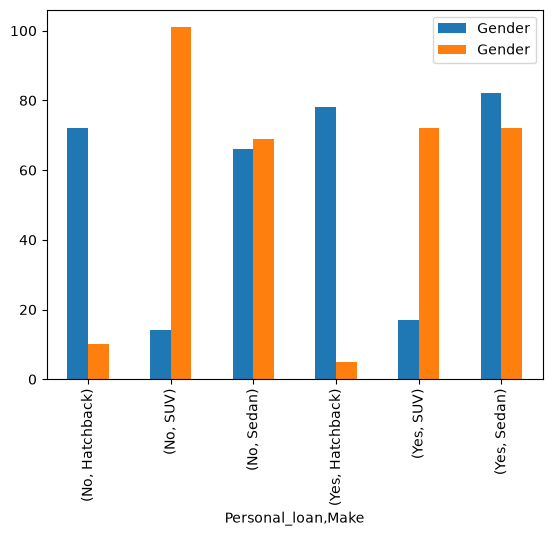

In [306]:
pd.concat([sample3,fem],axis=1).plot.bar()

# house_loan and make 

In [307]:
MaleData = car[car.Gender == "Male"][["House_loan","Make","Gender"]]
MaleData

,House_loan,Make,Gender
0,No,SUV,Male
4,No,SUV,Male
7,No,SUV,Male
8,No,SUV,Male
9,No,SUV,Male
...,...,...,...
1576,Yes,Hatchback,Male
1577,No,Hatchback,Male
1578,Yes,Hatchback,Male
1579,Yes,Hatchback,Male


In [308]:
FemaleData = car[car.Gender == "Female"][["House_loan","Make","Gender"]]
FemaleData

,House_loan,Make,Gender
1,No,SUV,Female
2,No,SUV,Female
3,No,SUV,Female
5,No,SUV,Female
6,No,SUV,Female
...,...,...,...
1350,No,Hatchback,Female
1389,No,Hatchback,Female
1503,No,Hatchback,Female
1518,No,Hatchback,Female


In [309]:
sample1 = MaleData.sample(329).groupby(["House_loan","Make"])["Gender"].count()
sample1

House_loan  Make     
No          Hatchback    90
            SUV          28
            Sedan        82
Yes         Hatchback    66
            Sedan        63
Name: Gender, dtype: int64

In [310]:
sample2 = MaleData.sample(329).groupby(["House_loan","Make"])["Gender"].count()
sample2

House_loan  Make     
No          Hatchback    92
            SUV          38
            Sedan        93
Yes         Hatchback    53
            Sedan        53
Name: Gender, dtype: int64

In [311]:
sample3 = MaleData.sample(329).groupby(["House_loan","Make"])["Gender"].count()
sample3

House_loan  Make     
No          Hatchback    85
            SUV          27
            Sedan        97
Yes         Hatchback    73
            Sedan        47
Name: Gender, dtype: int64

In [312]:
fem = FemaleData.groupby(["House_loan","Make"])["Gender"].count()
fem

House_loan  Make     
No          Hatchback     11
            SUV          151
            Sedan         82
Yes         Hatchback      4
            SUV           22
            Sedan         59
Name: Gender, dtype: int64

<Axes: xlabel='House_loan,Make'>

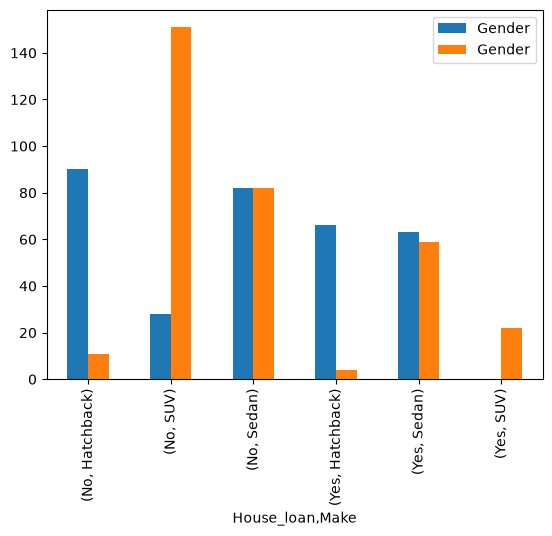

In [313]:
pd.concat([sample1,fem],axis = 1).plot.bar()

<Axes: xlabel='House_loan,Make'>

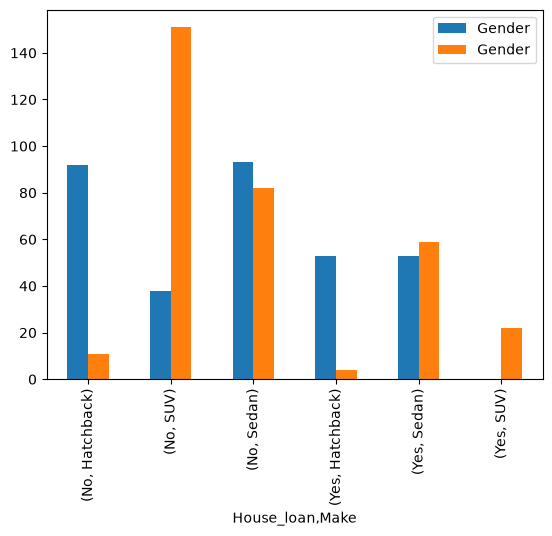

In [314]:
pd.concat([sample2,fem],axis = 1).plot.bar()

<Axes: xlabel='House_loan,Make'>

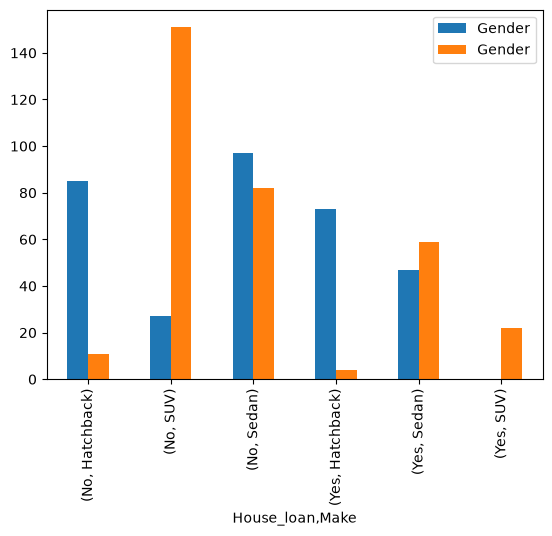

In [315]:
pd.concat([sample3,fem],axis = 1).plot.bar()

In [316]:
# With Home loan Male dosn't prefer suv almost a zero Male buysing suv with House loan 

# also house loan also affect the sale on female buyer of suv because with loan they mostly perfer seadan over the suv and hatchback



# partner working and make 

In [317]:
MaleData = car[car.Gender == "Male"][["Partner_working","Make"]]
MaleData

,Partner_working,Make
0,Yes,SUV
4,Yes,SUV
7,Yes,SUV
8,No,SUV
9,No,SUV
...,...,...
1576,No,Hatchback
1577,No,Hatchback
1578,No,Hatchback
1579,No,Hatchback


In [318]:
FemaleData = car[car.Gender == "Female"][["Partner_working","Make"]]
FemaleData

,Partner_working,Make
1,Yes,SUV
2,Yes,SUV
3,Yes,SUV
5,Yes,SUV
6,Yes,SUV
...,...,...
1350,No,Hatchback
1389,Yes,Hatchback
1503,Yes,Hatchback
1518,Yes,Hatchback


In [319]:
sample1 = MaleData.sample(329).groupby(["Partner_working","Make"])["Make"].count()
sample1

Partner_working  Make     
No               Hatchback    63
                 SUV          25
                 Sedan        66
Yes              Hatchback    87
                 SUV          16
                 Sedan        72
Name: Make, dtype: int64

In [320]:
sample2 = MaleData.sample(329).groupby(["Partner_working","Make"])["Make"].count()
sample2

Partner_working  Make     
No               Hatchback    67
                 SUV          18
                 Sedan        64
Yes              Hatchback    71
                 SUV          12
                 Sedan        97
Name: Make, dtype: int64

In [321]:
sample3 = MaleData.sample(329).groupby(["Partner_working","Make"])["Make"].count()
sample3

Partner_working  Make     
No               Hatchback    77
                 SUV          15
                 Sedan        60
Yes              Hatchback    74
                 SUV           8
                 Sedan        95
Name: Make, dtype: int64

In [322]:
fem = FemaleData.groupby(["Partner_working","Make"])["Make"].count()
fem

Partner_working  Make     
No               Hatchback     7
                 SUV          80
                 Sedan        64
Yes              Hatchback     8
                 SUV          93
                 Sedan        77
Name: Make, dtype: int64

<Axes: xlabel='Partner_working,Make'>

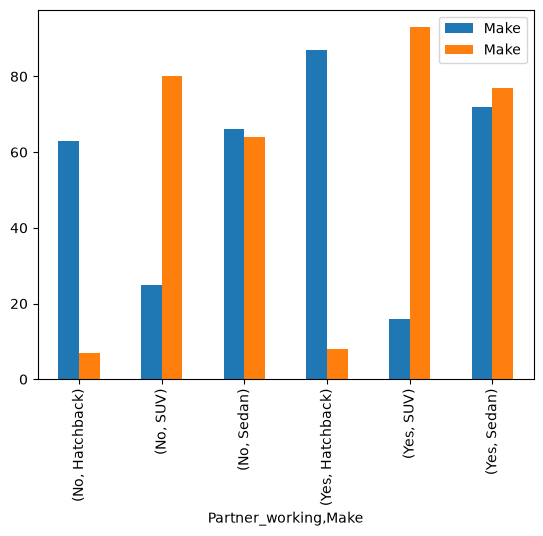

In [323]:
pd.concat([sample1,fem],axis=1).plot.bar()

<Axes: xlabel='Partner_working,Make'>

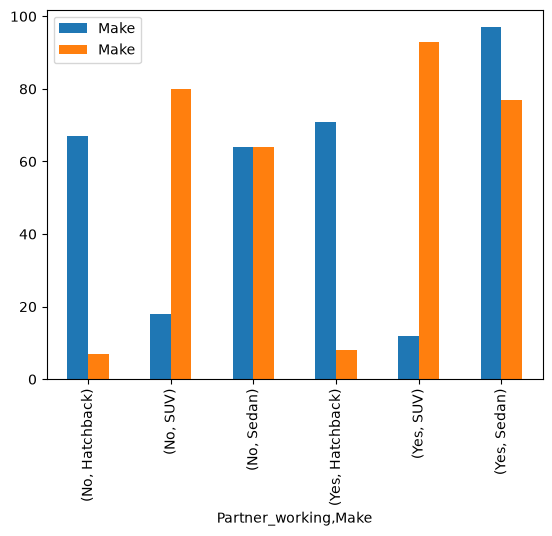

In [324]:
pd.concat([sample2,fem],axis=1).plot.bar()

<Axes: xlabel='Partner_working,Make'>

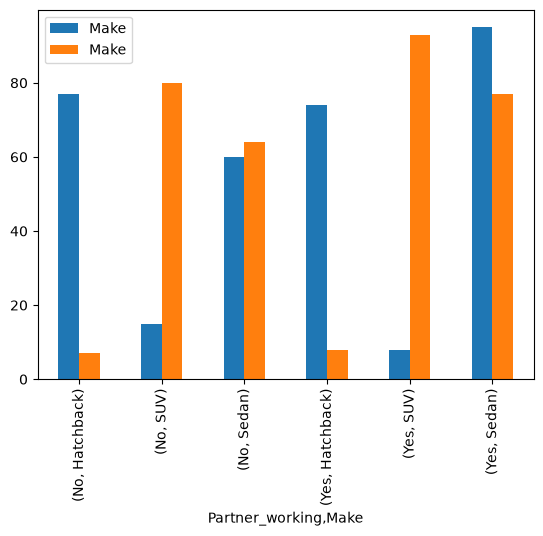

In [325]:
pd.concat([sample3,fem],axis=1).plot.bar()

# Salary and make

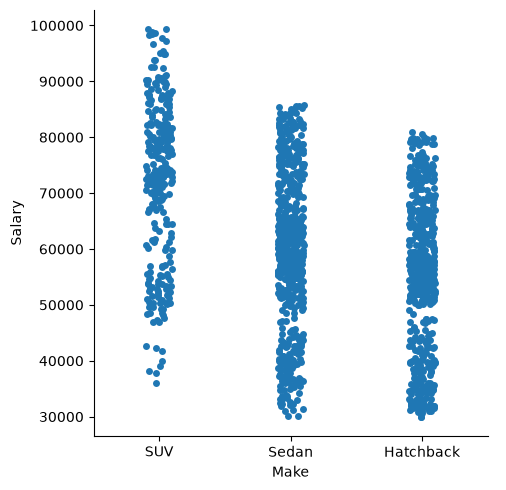

In [371]:
sns.catplot(data= car,x = "Make", y = "Salary",kind="strip")

In [ ]:
# people who salary near about 40k then are started chosing suv 

#people who has salary above 30 they prefered hatchback and seadan both 

# above 90k people are mostly prefer suv 

# we can say that mostly people are intrested in buying a seadan and hatchback 

# no of dependents and make

In [349]:
MaleData = car[car.Gender =="Male"][["No_of_Dependents","Make"]]
MaleData

,No_of_Dependents,Make
0,4,SUV
4,3,SUV
7,4,SUV
8,4,SUV
9,3,SUV
...,...,...
1576,2,Hatchback
1577,4,Hatchback
1578,2,Hatchback
1579,3,Hatchback


In [350]:
FemaleData = car[car.Gender == "Male"][["No_of_Dependents","Make"]]
FemaleData

,No_of_Dependents,Make
0,4,SUV
4,3,SUV
7,4,SUV
8,4,SUV
9,3,SUV
...,...,...
1576,2,Hatchback
1577,4,Hatchback
1578,2,Hatchback
1579,3,Hatchback


In [352]:
sample1 = MaleData.sample(329).groupby(["No_of_Dependents","Make"])["Make"].count()
sample1

No_of_Dependents  Make     
0                 Hatchback     4
1                 Hatchback     4
                  Sedan        46
2                 Hatchback    44
                  SUV           8
                  Sedan        51
3                 Hatchback    63
                  SUV          17
                  Sedan        45
4                 Hatchback    26
                  SUV          10
                  Sedan        11
Name: Make, dtype: int64

In [353]:
sample2 = MaleData.sample(329).groupby(["No_of_Dependents","Make"])["Make"].count()
sample2

No_of_Dependents  Make     
0                 Hatchback     4
                  SUV           1
1                 Hatchback     3
                  Sedan        29
2                 Hatchback    43
                  SUV           7
                  Sedan        59
3                 Hatchback    65
                  SUV          21
                  Sedan        46
4                 Hatchback    31
                  SUV          10
                  Sedan        10
Name: Make, dtype: int64

In [354]:
sample3 = MaleData.sample(329).groupby(["No_of_Dependents","Make"])["Make"].count()
sample3

No_of_Dependents  Make     
0                 Hatchback     5
1                 Hatchback     2
                  Sedan        33
2                 Hatchback    59
                  SUV           5
                  Sedan        44
3                 Hatchback    67
                  SUV          18
                  Sedan        53
4                 Hatchback    25
                  SUV           7
                  Sedan        11
Name: Make, dtype: int64

In [355]:
fem = FemaleData.groupby(["No_of_Dependents","Make"])["Make"].count()
fem

No_of_Dependents  Make     
0                 Hatchback     15
                  SUV            2
1                 Hatchback     11
                  Sedan        119
2                 Hatchback    176
                  SUV           33
                  Sedan        213
3                 Hatchback    249
                  SUV           58
                  Sedan        184
4                 Hatchback    116
                  SUV           31
                  Sedan         45
Name: Make, dtype: int64

<Axes: xlabel='No_of_Dependents,Make'>

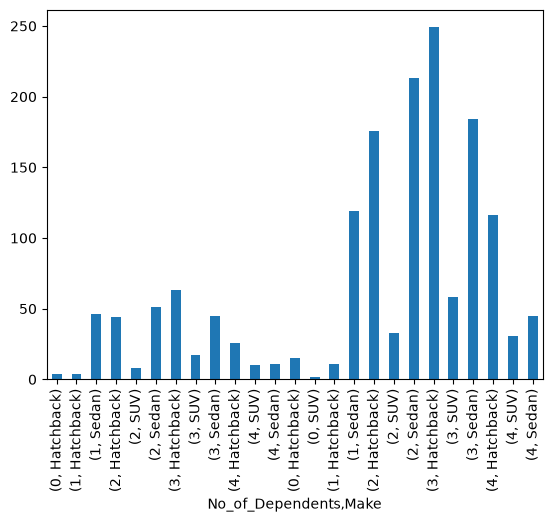

In [356]:
pd.concat([sample1,fem]).plot.bar()

<Axes: xlabel='No_of_Dependents,Make'>

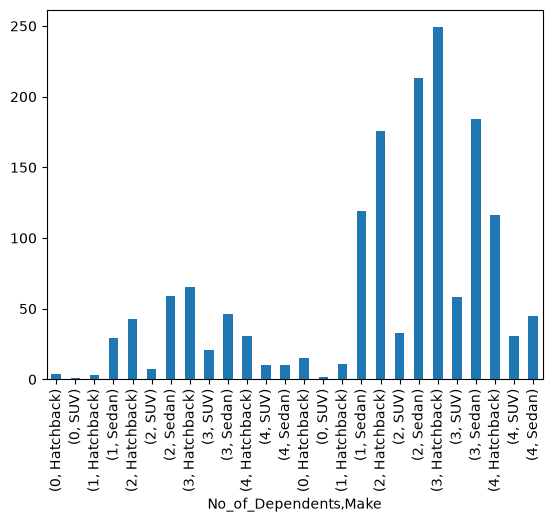

In [357]:
pd.concat([sample2,fem]).plot.bar()

<Axes: xlabel='No_of_Dependents,Make'>

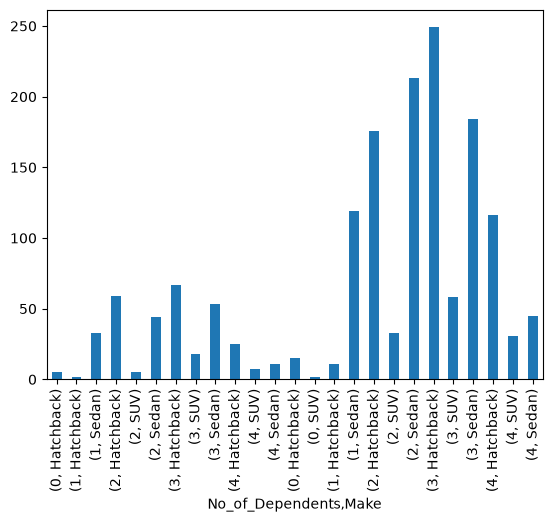

In [358]:
pd.concat([sample3,fem]).plot.bar()

In [359]:
# most when any people have number of dependets are 3 they are mostly prefer Hatchback

# if number of dependets are 2 so mostly people choose the seadan 

# Partner_salary and Make

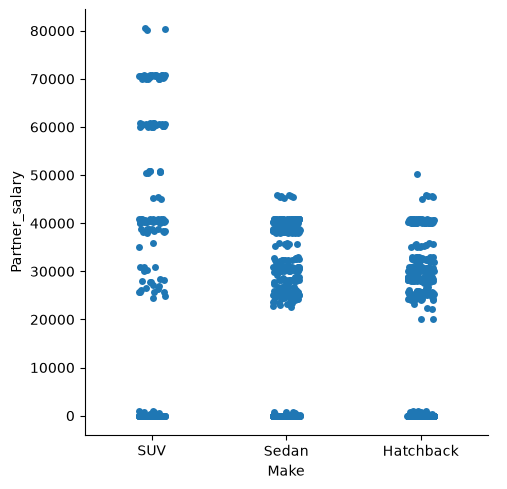

In [ ]:
sns.catplot(data= car,x = "Make", y = "Partner_salary",kind="strip")

In [ ]:
# when partner salary is too good and we can say that above 50 thousand then family and people are choosing suv most 

# when partner salary is under 50 mostly people move towards seadan and hatchback most 

# without partner salary like all people same interested in all types of car 

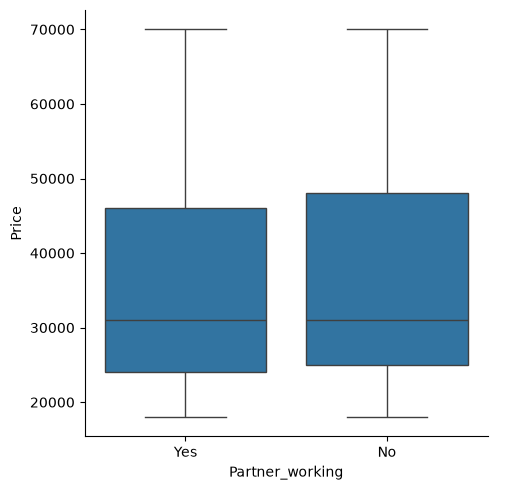

In [ ]:
sns.catplot(data= car,x = "Partner_working", y = "Price" , kind="box")

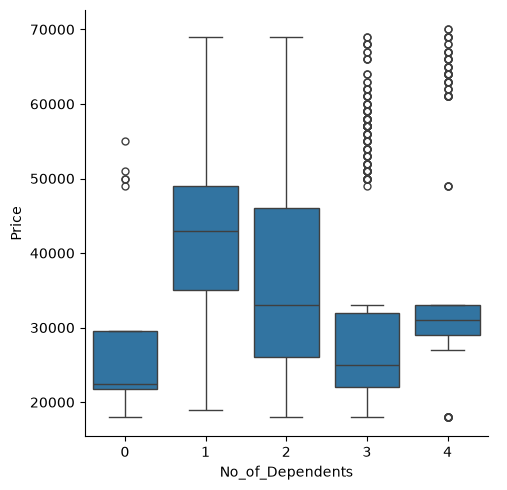

In [ ]:
sns.catplot(data= car,x = "No_of_Dependents", y = "Price" , kind="box")

<Axes: xlabel='Gender,Profession,Make'>

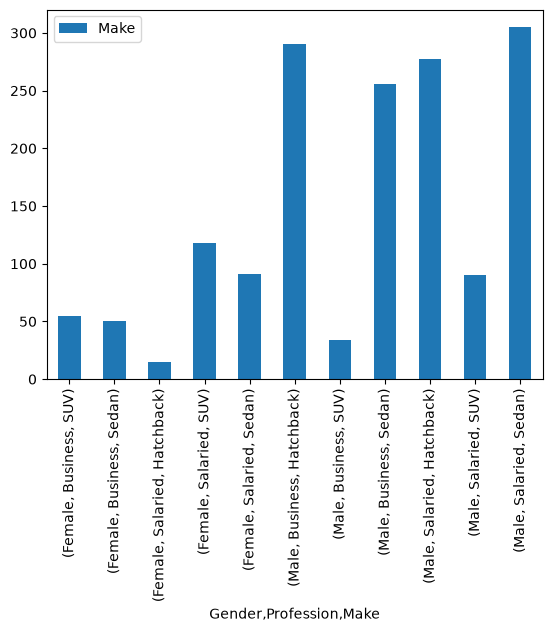

In [ ]:
pd.DataFrame(car.groupby(["Gender","Profession","Make"])["Make"].count()).plot.bar()

In [ ]:
# male salaried are more inrested in seadan and male business are more intrested in hatchback 

<Axes: xlabel='Gender,Partner_working,Make'>

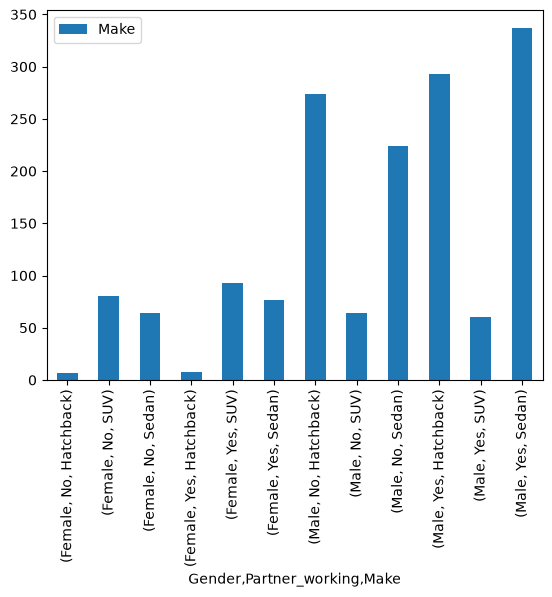

In [ ]:
pd.DataFrame(car.groupby(["Gender","Partner_working","Make"])["Make"].count()).plot.bar()

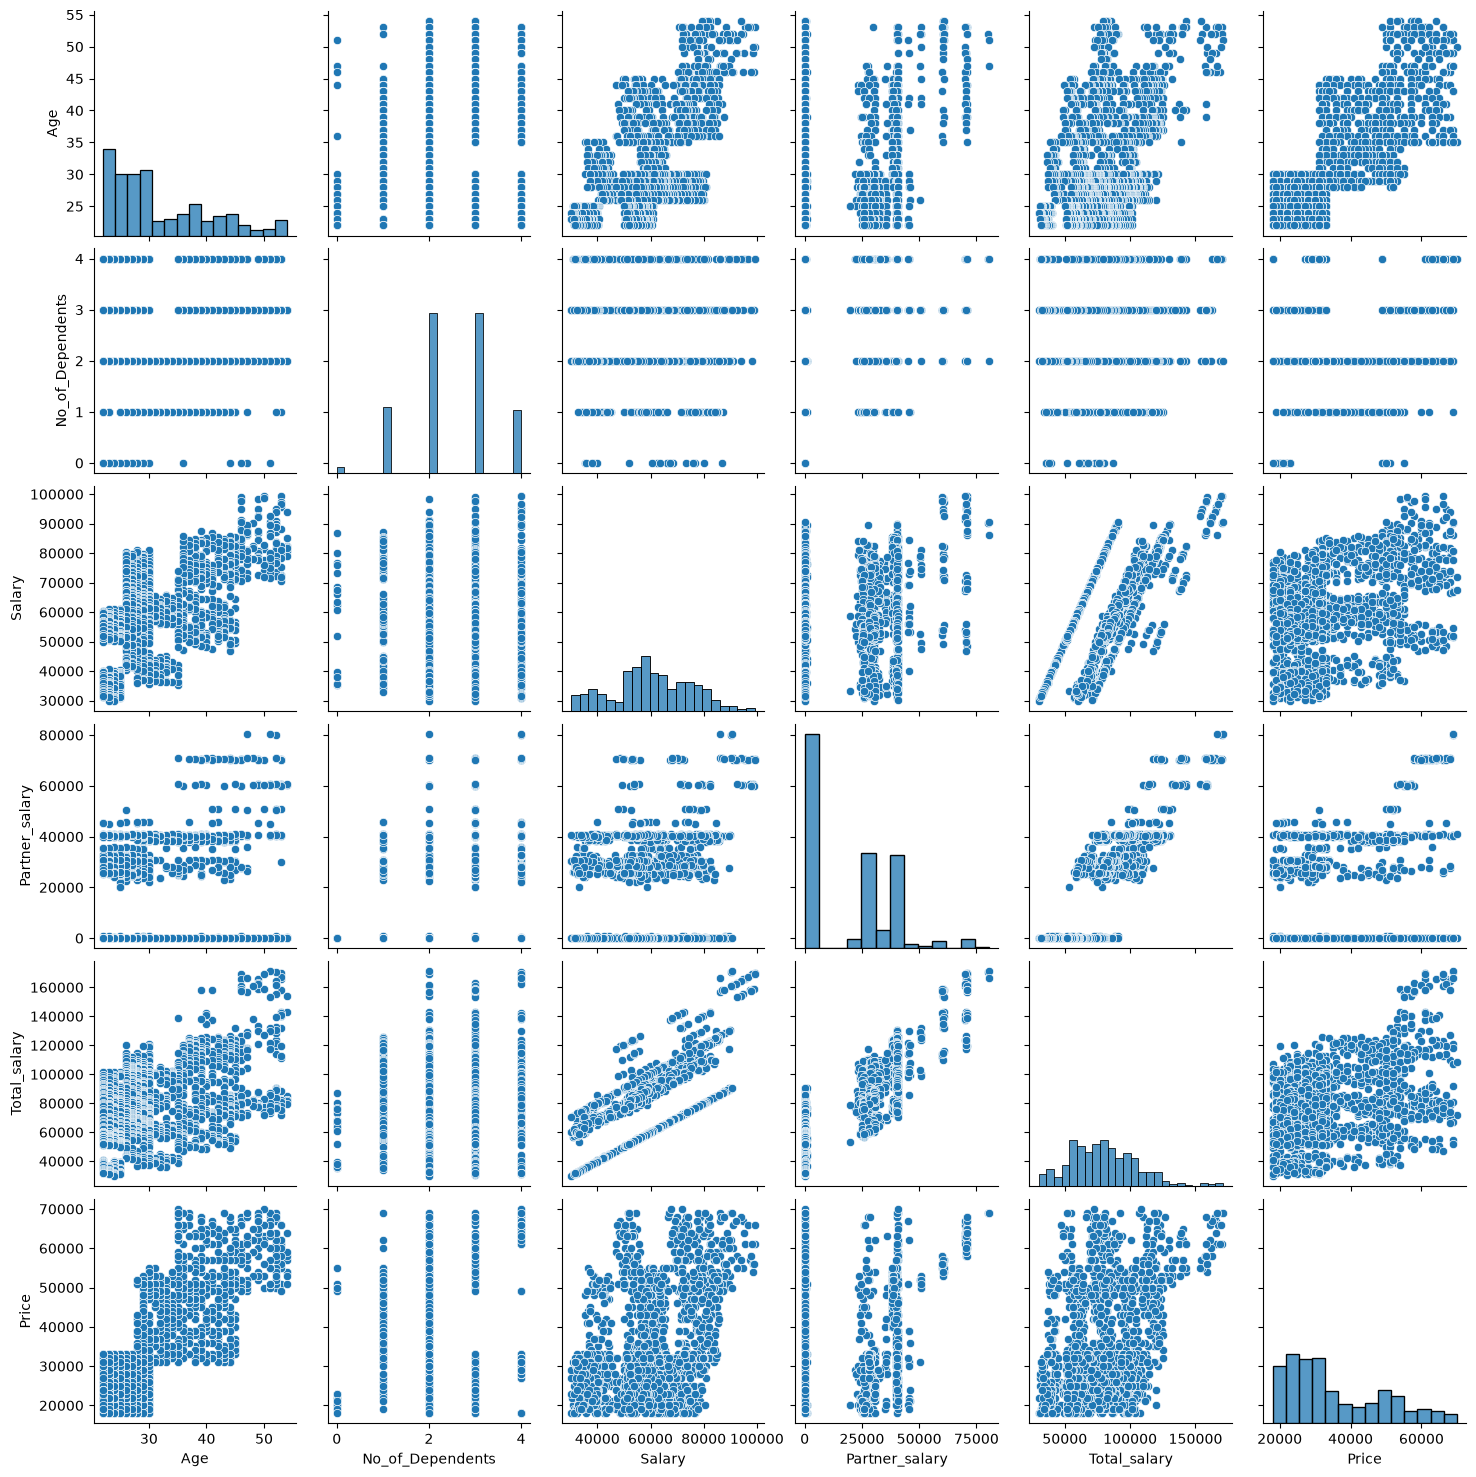

In [ ]:
sns.pairplot(car)

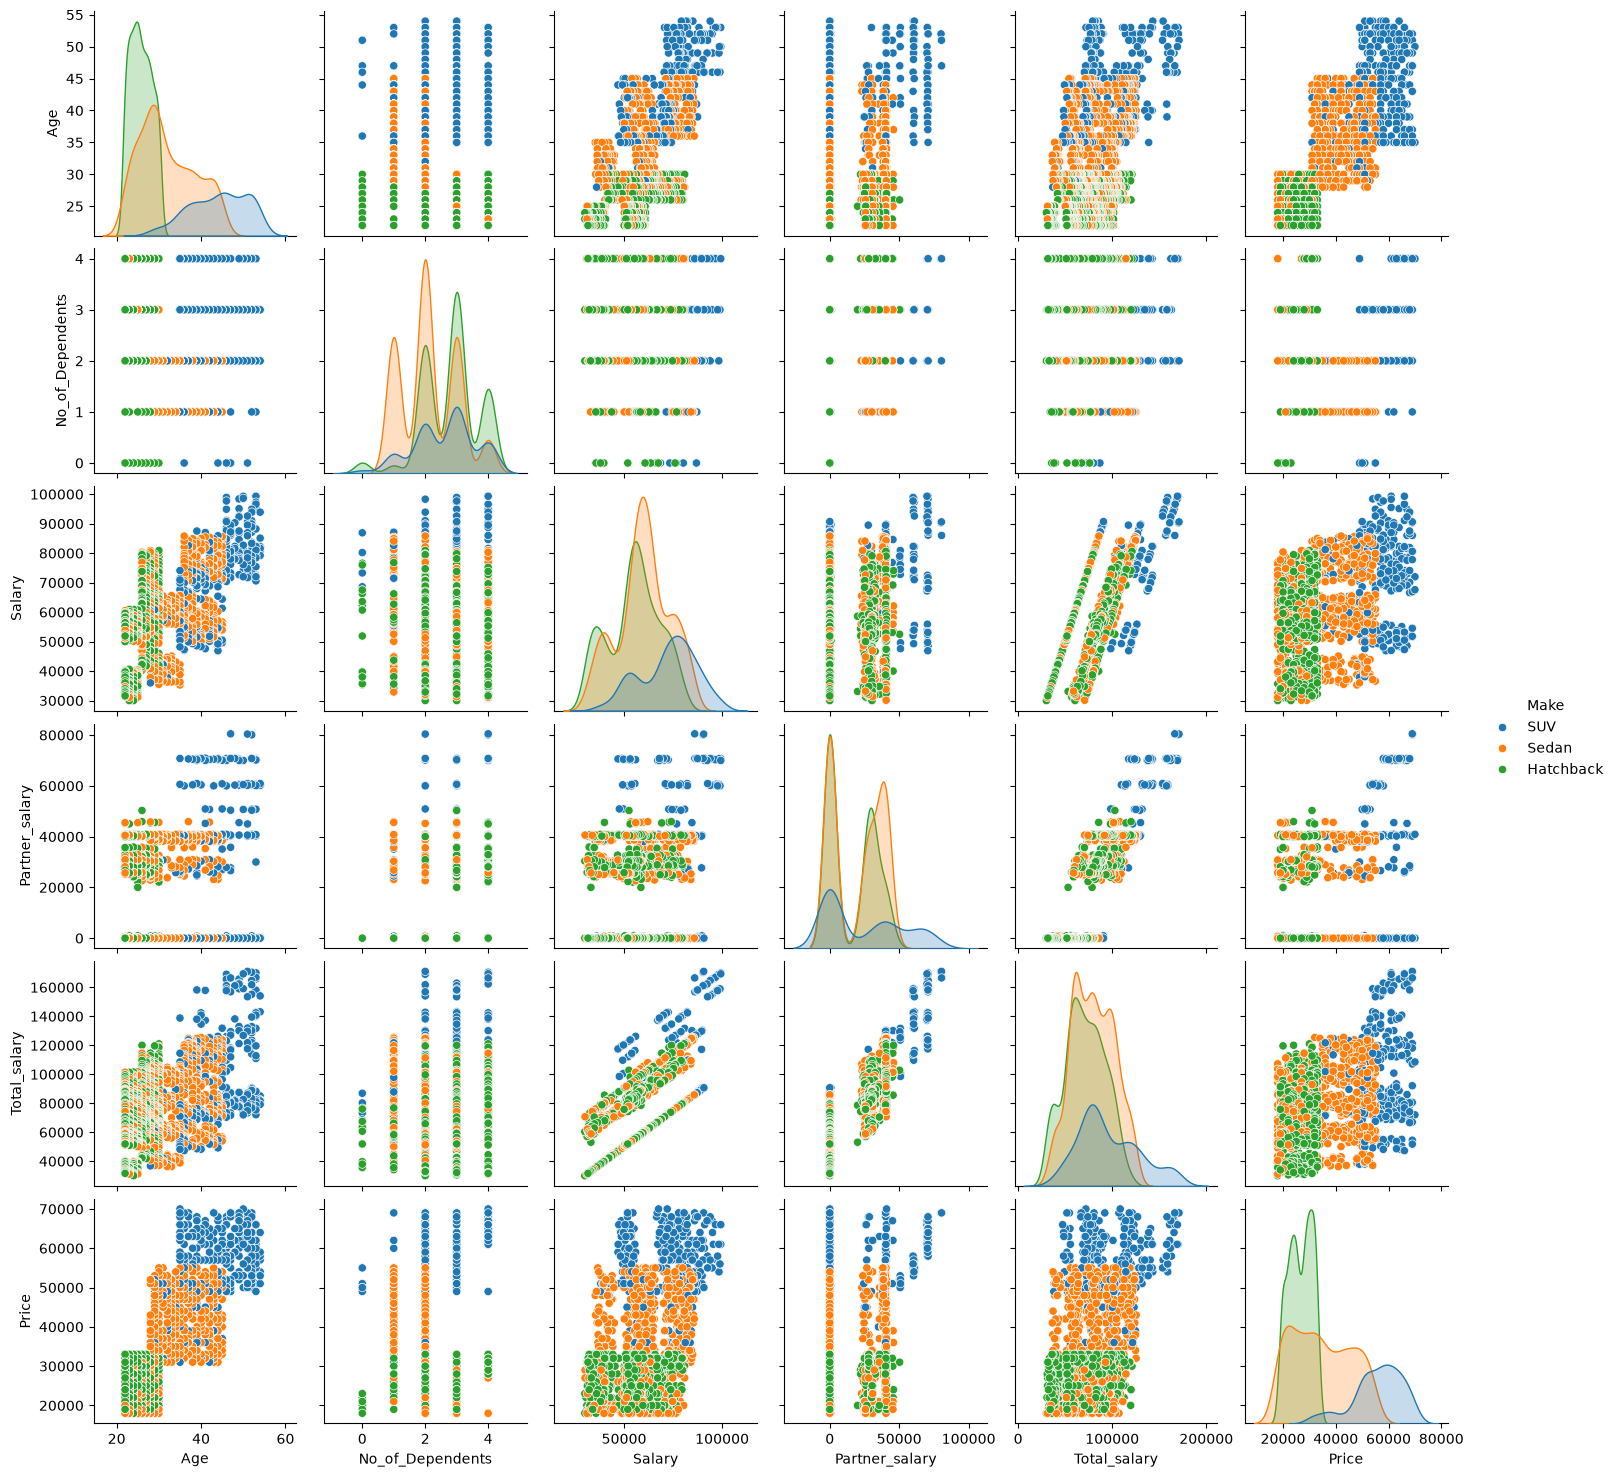

In [ ]:
sns.pairplot(car,hue="Make")

data - cleaning


data analysis


data visualization and story telling 


reportinh



context -> visualization -> insights -> Action 


Story ->

last year month:
monthly -> 102 105 110


audience : CEO : 

reporting : 

doc or pdf : insights with appropriate charts : sugeestion :

